Using device: cpu
loading annotations into memory...
Done (t=0.60s)
creating index...
index created!


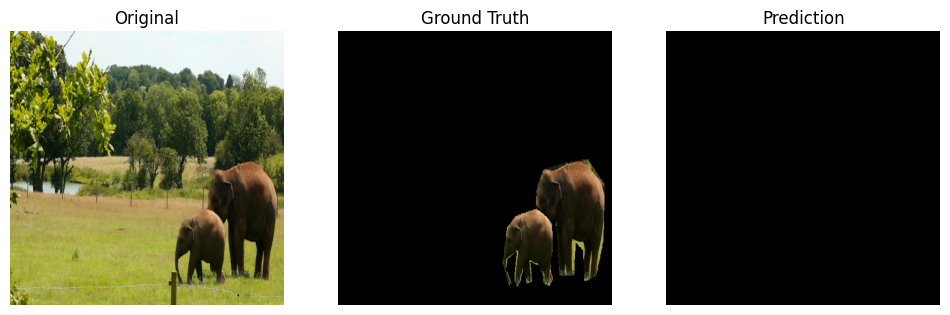

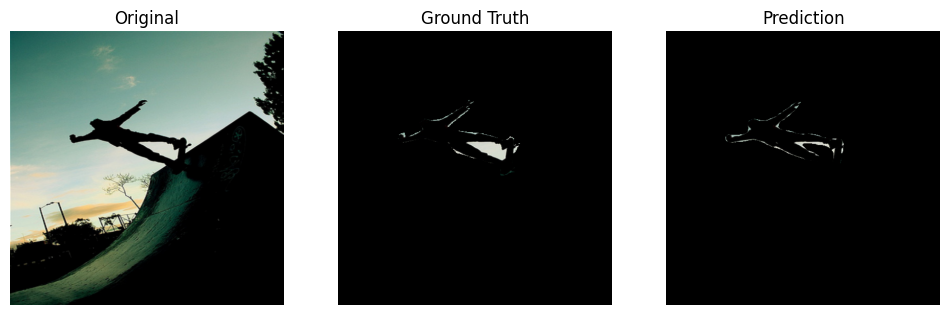

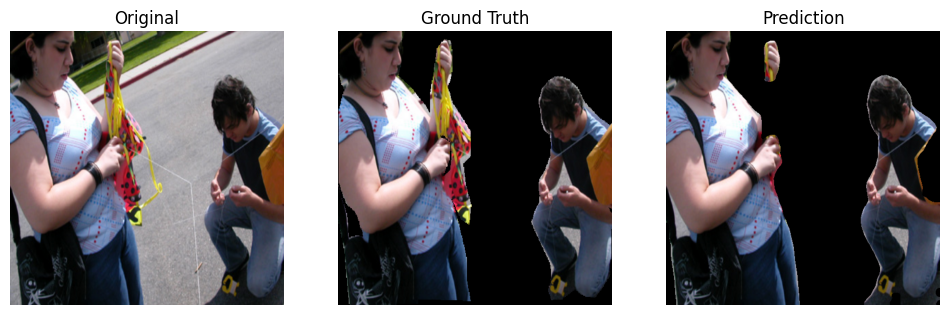

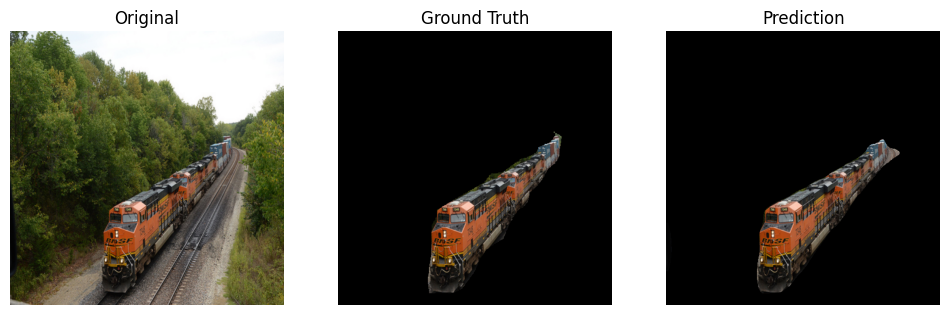

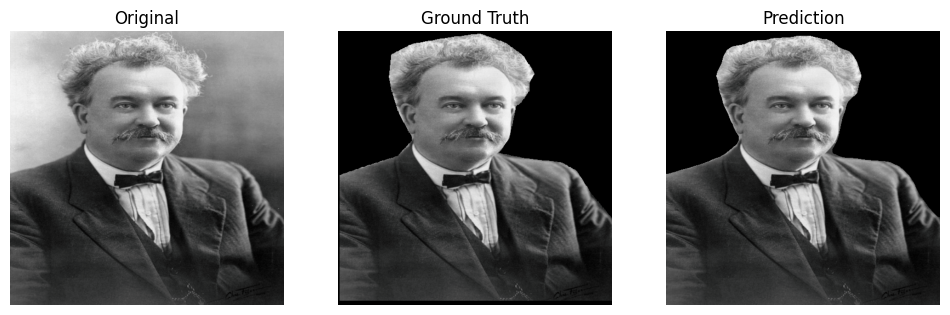

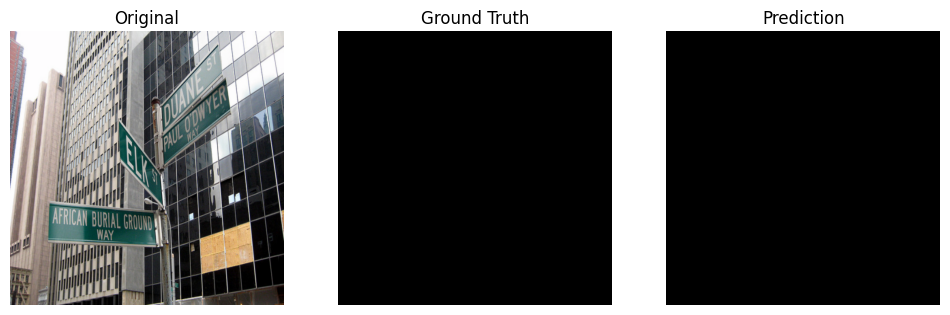

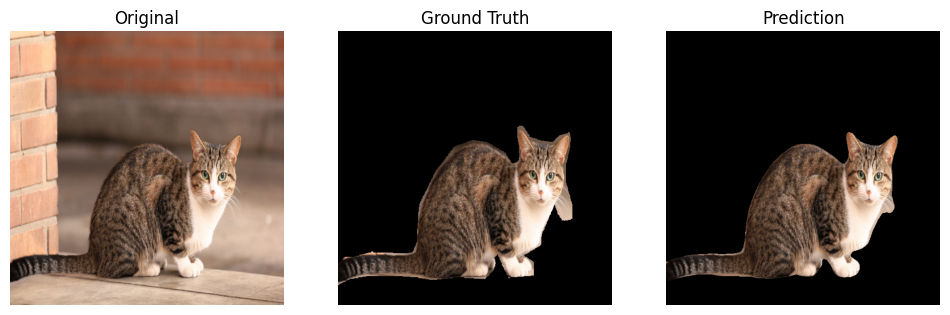


Average Pixel Accuracy: 0.9618
Average Binary IoU: 0.7708


In [72]:
import os
import zipfile
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
from scipy.ndimage import median_filter

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from pycocotools.coco import COCO
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

# =======================
# Device
# =======================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =======================
# Download COCO subset
# =======================
root = "./coco/val2017"
ann_dir = "./coco/annotations"
annFile = os.path.join(ann_dir, "instances_val2017.json")

def download_file(url, save_path):
    if not os.path.exists(save_path):
        print(f"Downloading {url} ...")
        urllib.request.urlretrieve(url, save_path)
        print("Download complete.")

if not os.path.exists(root):
    os.makedirs(root, exist_ok=True)
    url_images = "http://images.cocodataset.org/zips/val2017.zip"
    zip_path = "val2017.zip"
    download_file(url_images, zip_path)
    print("Extracting images...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("./coco")
    os.remove(zip_path)

if not os.path.exists(annFile):
    os.makedirs(ann_dir, exist_ok=True)
    url_ann = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"
    zip_path_ann = "annotations.zip"
    download_file(url_ann, zip_path_ann)
    print("Extracting annotations...")
    with zipfile.ZipFile(zip_path_ann, 'r') as zip_ref:
        zip_ref.extractall("./coco")
    os.remove(zip_path_ann)

# =======================
# Dataset Class
# =======================
class CocoSegmentationDataset(Dataset):
    def __init__(self, root, annFile, image_size=512, transform=None, subset_size=30):
        self.coco = COCO(annFile)
        self.root = root
        self.transform = transform
        self.image_size = image_size
        self.img_ids = list(self.coco.imgs.keys())
        random.shuffle(self.img_ids)
        self.img_ids = self.img_ids[:subset_size]

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        img_info = self.coco.loadImgs(img_id)[0]
        path = os.path.join(self.root, img_info['file_name'])
        image = Image.open(path).convert("RGB")

        # Transform image
        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(transforms.Resize((self.image_size, self.image_size))(image))

        # Binary mask creation
        mask = np.zeros((self.image_size, self.image_size), dtype=np.uint8)
        for ann in anns:
            m = self.coco.annToMask(ann)
            m_resized = np.array(transforms.Resize(
                (self.image_size, self.image_size),
                interpolation=Image.NEAREST)(Image.fromarray(m)))
            mask = np.maximum(mask, m_resized)

        return image, torch.tensor(mask, dtype=torch.long)

# =======================
# Transform & DataLoader
# =======================
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_dataset = CocoSegmentationDataset(root, annFile, transform=transform, subset_size=30)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

# =======================
# Load Pretrained Model
# =======================
weights = DeepLabV3_ResNet50_Weights.DEFAULT
model = deeplabv3_resnet50(weights=weights)
model.to(device)
model.eval()

# =======================
# Utility Functions
# =======================
def extract_object_rgb(image, mask):
    obj = np.zeros_like(image, dtype=np.uint8)
    obj[mask > 0] = image[mask > 0]
    return obj

def pixel_accuracy(pred, target):
    correct = (pred == target).sum().item()
    total = target.numel()
    return correct / total

def binary_iou(pred, target):
    intersection = (pred & target).sum().item()
    union = (pred | target).sum().item()
    if union == 0:
        return 1.0
    return intersection / union

# =======================
# Visualization + Metrics
# =======================
def visualize_samples_and_metrics(model, data_loader, num_samples=10, threshold=0.5):
    model.eval()
    shown = 0
    total_pixel_acc = 0
    total_iou = 0
    count = 0

    with torch.no_grad():
        for images, masks in data_loader:
            images = images.to(device)
            outputs = model(images)["out"]  # [B, 21, H, W]

            # Convert to binary mask: any class > 0 is object
            preds_binary = torch.argmax(outputs, dim=1)
            preds_binary = (preds_binary > 0).long()

            # Median filter smoothing
            preds_np = preds_binary.cpu().numpy()
            preds_np = np.array([median_filter(p, size=5) for p in preds_np])
            preds_binary = torch.tensor(preds_np)

            for i in range(len(images)):
                if shown >= num_samples:
                    avg_pixel_acc = total_pixel_acc / count
                    avg_iou = total_iou / count
                    print(f"\nAverage Pixel Accuracy: {avg_pixel_acc:.4f}")
                    print(f"Average Binary IoU: {avg_iou:.4f}")
                    return

                img = images[i].cpu()
                img = img * torch.tensor([0.229,0.224,0.225]).view(3,1,1) + torch.tensor([0.485,0.456,0.406]).view(3,1,1)
                img = torch.clamp(img, 0, 1).permute(1,2,0).numpy()
                img = (img*255).astype(np.uint8)

                gt_mask = masks[i].cpu()
                pred_mask = preds_binary[i]

                total_pixel_acc += pixel_accuracy(pred_mask, gt_mask)
                total_iou += binary_iou(pred_mask, gt_mask)
                count += 1

                # Visualization
                gt_obj = extract_object_rgb(img, gt_mask.numpy())
                pred_obj = extract_object_rgb(img, pred_mask.numpy())

                fig, axs = plt.subplots(1, 3, figsize=(12,4))
                axs[0].imshow(img); axs[0].set_title("Original"); axs[0].axis("off")
                axs[1].imshow(gt_obj); axs[1].set_title("Ground Truth"); axs[1].axis("off")
                axs[2].imshow(pred_obj); axs[2].set_title("Prediction"); axs[2].axis("off")
                plt.show()

                shown += 1

# =======================
# Run
# =======================
visualize_samples_and_metrics(model, val_loader, num_samples=7)
